In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pickle

In [3]:
#device configuration
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
#Parameters
input_size = 784
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

In [5]:
#Fashion MNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(root='./data',
                                           train=True,
                                           transform=transforms.ToTensor(),
                                           download=True)

test_dataset = torchvision.datasets.FashionMNIST(root='./data',
                                          train=False,
                                          transform=transforms.ToTensor())

100%|██████████| 26.4M/26.4M [00:01<00:00, 21.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 337kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.9MB/s]


In [6]:
#Data loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

In [7]:
#neural network class
class NeuralNet(nn.Module):
  def __init__(self,input_size,num_classes):
    super(NeuralNet, self).__init__()
    self.l1=nn.Linear(input_size,16)
    self.b1l1=nn.Linear(16,8)
    self.b2l1=nn.Linear(16,12)
    self.b1relu=nn.ReLU()
    self.b2l2=nn.Linear(12,8)
    self.l2=nn.Linear(16,10)

  def forward(self,x):
    a=self.l1(x)
    out1=self.b1l1(a)
    b=out1
    out1=self.b1relu(out1)
    out1=b+out1
    out2=self.b2l1(a)
    out2=self.b2l2(out2)
    out = torch.cat((out1, out2), dim=1)
    c=self.l2(out)
    return c


In [8]:
#Model
model = NeuralNet(input_size, num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
#Lists
train_losses=list()
train_accuracies=list()
val_losses=list()
val_accuracies=list()

In [10]:
# Train the model
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    n_correct = 0
    n_samples = 0
    for i, (images, labels) in enumerate(train_loader):
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        _,predict = torch.max(outputs.data, 1)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        n_samples += labels.size(0)
        n_correct += (predict == labels).sum().item()

    train_acc = 100 * n_correct/n_samples
    train_loss=loss.item()

# Test the model
    with torch.no_grad():
      n_correct = 0
      n_samples = 0
      val_loss=0
      for images, labels in test_loader:
          images = images.reshape(-1, 28*28).to(device)
          labels = labels.to(device)
          outputs = model(images)
        # max returns (value ,index)
          _, predicted = torch.max(outputs.data, 1)

          #loss for current batch
          loss=criterion(outputs,labels)
          val_loss += loss.item()

          n_samples += labels.size(0)
          n_correct += (predicted == labels).sum().item()

      val_acc = 100.0 * n_correct / n_samples
      val_loss = val_loss/len(test_loader)
      print(f'Epoch [{epoch+1}/{num_epochs}],Train_acc: {train_acc:.4f}%,Train_loss:{train_loss:.4f},Val_acc:{val_acc}%,Val_loss:{val_loss:.4f}')

      #save the values to list
      train_losses.append(train_loss)
      train_accuracies.append(train_acc)
      val_accuracies.append(val_acc)
      val_losses.append(val_loss)


Epoch [1/5],Train_acc: 75.5167%,Train_loss:0.4054,Val_acc:81.62%,Val_loss:0.5293
Epoch [2/5],Train_acc: 83.4967%,Train_loss:0.4012,Val_acc:83.16%,Val_loss:0.4765
Epoch [3/5],Train_acc: 84.7167%,Train_loss:0.5071,Val_acc:83.37%,Val_loss:0.4696
Epoch [4/5],Train_acc: 85.0267%,Train_loss:0.3683,Val_acc:83.16%,Val_loss:0.4766
Epoch [5/5],Train_acc: 85.7100%,Train_loss:0.4204,Val_acc:84.36%,Val_loss:0.4389


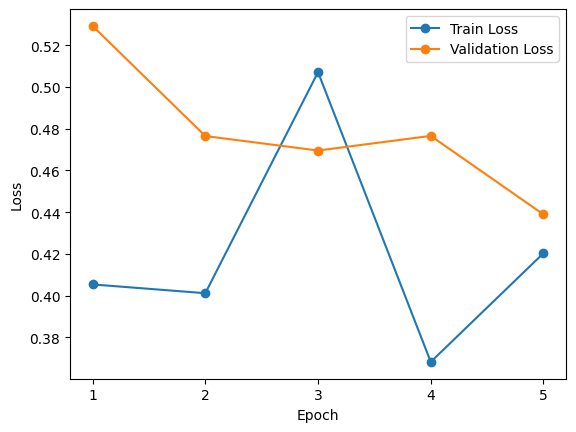

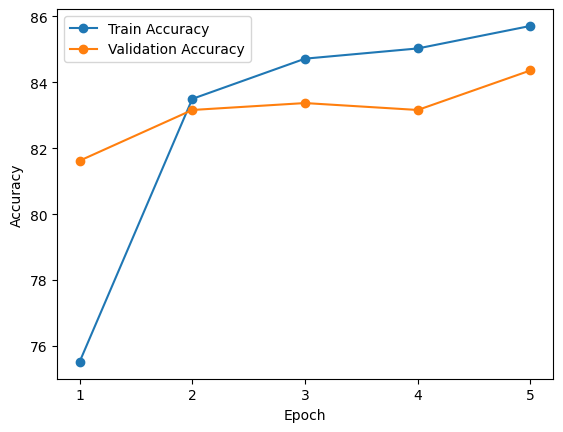

In [11]:
#graphs

epochs = range(1, num_epochs + 1)

#losses
plt.plot(epochs, train_losses, marker='o',label='Train Loss')
plt.plot(epochs, val_losses, marker='o',label='Validation Loss')

plt.xticks(list(epochs))

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#accuracies
plt.plot(epochs, train_accuracies, marker='o',label='Train Accuracy')
plt.plot(epochs, val_accuracies, marker='o',label='Validation Accuracy')

plt.xticks(list(epochs))

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [12]:
#Dump weigths
import pickle

with open("model_weights.pkl", "wb") as f:
    pickle.dump(model.state_dict(), f)

In [13]:
# Generate submission.csv

import pandas as pd

predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.reshape(-1, 28*28).to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        predictions.extend(predicted.cpu().numpy())

submission = pd.DataFrame({
    'id': range(len(predictions)),
    'prediction': predictions
})

submission.to_csv('submission.csv', index=False)

print("submission.csv generated successfully!")
print(submission.head())

submission.csv generated successfully!
   id  prediction
0   0           9
1   1           2
2   2           1
3   3           1
4   4           6


In [15]:
from google.colab import files

files.download("model_weights.pkl")
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>